### Sample pipeline for analyzing various visual properties of videos across different categories.

The different sections are meant to be standalone scripts. To avoid carryovers with variables etc restart kernel before each section.

The RDMs generated here could be used in RSA-like analyses, but make sure to process the data further based on the analysis you're going to use. 

For instance, in RSA, people often normalize the data by z-scoring or mean subtracting before computing the distances


#### Section 1: editing videos as needed (resolution, frame rate, size, duration etc)

By using some moviepy functionalities, here you can change the fps, duration etc of videos. 

In [ ]:
from moviepy import VideoFileClip
import os

base_dir = os.environ.get("DYLOC_STIMULI_DIR", "./stimuli")  # folder with dyloc_bodies/dyloc_faces/dyloc_objects/dyloc_scenes/dyloc_words subfolders
input_folder = os.path.join(base_dir, 'final_stimuli', 'dyloc_faces_origsize')
output_folder = os.path.join(base_dir, 'dyloc_faces')

os.makedirs(output_folder, exist_ok=True)

duration = 2  # seconds
target_fps = 30              # change fps
bitrate = "2000k"            # change bitrate drastically

for filename in os.listdir(input_folder):
    if filename.endswith('.mp4'):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        clip = VideoFileClip(input_path)
        end_time = min(duration, clip.duration)
        clip = clip.resized(0.5)
        (
            clip.subclipped(0, end_time)
                .without_audio()
                .write_videofile(
                    output_path,
                    codec='libx264',
                    bitrate=bitrate,
                    fps=target_fps,
                    audio=False,
                    threads=2,
                    ffmpeg_params=["-movflags", "+faststart"]  # improves PsychoPy load
                )
        )

        clip.close()


#### Section 2: Category-Average Frame Visualization
This analysis computes a single representative "average frame" for each stimulus category by performing a two-level averaging process. 

First, for each video within a category, all frames are averaged temporally to create a mean RGB image representing that video's typical appearance.

Second, these video-level average frames are aggregated across all exemplars within the category to produce a single category-level prototype image. This double-averaging collapses both temporal dynamics (within videos) and exemplar variability (across videos) to reveal the central tendency of visual features that define each category. The resulting composite images highlight shared low-level properties such as dominant colors, spatial layouts, and brightness distributions that are consistent across exemplars, providing an intuitive visualization of what makes each category visually distinctive at the pixel level.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from moviepy import VideoFileClip
from datetime import date

# Use the trimmed video folders
# Base directory and category folders
base_dir = os.environ.get("DYLOC_STIMULI_DIR", "./stimuli")  # folder with dyloc_bodies/dyloc_faces/dyloc_objects/dyloc_scenes/dyloc_words subfolders
categories = [
    "dyloc_faces",
    "dyloc_scenes",
    "dyloc_bodies",
    "dyloc_objects",
    "dyloc_words"
]

category_avg_frames = {}

for category in categories:
    folder = os.path.join(base_dir, category)
    label = category.replace("dyloc_", "")
    video_averages = []
    file_count = 0
    skipped = []

    for fname in os.listdir(folder):
        if fname.endswith(".mp4"):
            path = os.path.join(folder, fname)
            try:
                clip = VideoFileClip(path)
                frames = []
                for frame in clip.iter_frames():  # Use all frames
                    frame = frame.astype(np.float32) / 255.0 # normalization
                    frames.append(frame)
                if frames:
                    avg_video = np.mean(np.stack(frames), axis=0)
                    video_averages.append(avg_video)
                    file_count += 1
            except Exception as e:
                skipped.append(fname)
                print(f"Skipped {fname}: {e}")

    if video_averages:
        category_avg = np.mean(np.stack(video_averages), axis=0)
        category_avg_frames[label] = category_avg
        print(f"✅ {label}: {file_count} videos averaged")
    else:
        print(f"No usable videos found for {label}")

    if skipped:
        print(f"Skipped {len(skipped)} in {label}: {skipped}")



✅ faces: 80 videos averaged
✅ scenes: 80 videos averaged
✅ bodies: 80 videos averaged
✅ objects: 80 videos averaged
✅ words: 80 videos averaged


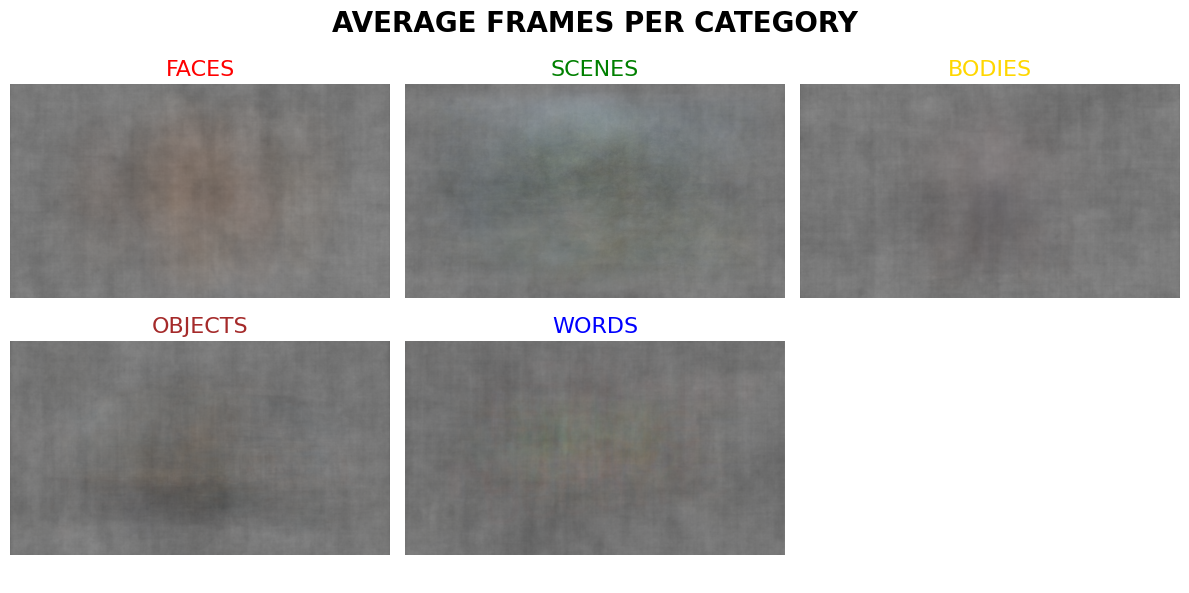

In [3]:
# === Plotting the final average frames ===
# For visualization, lab colors for the categories
color_map = {
    "faces": "red",
    "bodies": "gold",
    "scenes": "green",
    "objects": "brown",
    "words": "blue"
}

# Define custom order for the visuals
order = ["faces", "scenes", "bodies", "objects", "words"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, label in enumerate(order):
    if label in category_avg_frames:
        ax = axes[i]
        ax.imshow(category_avg_frames[label])
        ax.set_title(label.upper(), fontsize=16, color=color_map[label])
        ax.axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')


today = date.today().isoformat()  # YYYY-MM-DD

plt.suptitle("AVERAGE FRAMES PER CATEGORY", fontsize=20, weight="bold")
plt.tight_layout()
plt.savefig(f"average_frames_per_category_{today}.png",
            dpi=300, bbox_inches="tight")
plt.show()


#### Section 3: A pixelwise RDM for general visual appearance

This analysis computes a representational dissimilarity matrix (RDM) for each video. 

Each video is reduced to a single representative frame by averaging RGB pixel values across all temporal frames, creating a static "summary image" that captures the dominant color palette and spatial layout. 

This temporal averaging removes motion and dynamic information, instead representing what a video "looks like on average" in terms of color distribution and brightness patterns. 

Videos are then compared using correlation distance on their flattened RGB vectors, revealing which videos share similar overall visual appearance regardless of temporal dynamics. This approach shouldn't be used to get a sense of the motion-related characteristics of a video. 

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from datetime import date


# Define directory for videos in different folders
base_dir = os.environ.get("DYLOC_STIMULI_DIR", "./stimuli")  # folder with dyloc_bodies/dyloc_faces/dyloc_objects/dyloc_scenes/dyloc_words subfolders
target_folders = {
    'dyloc_bodies': 'Bodies',
    'dyloc_faces': 'Faces',
    'dyloc_objects': 'Objects',
    'dyloc_scenes': 'Scenes',
    'dyloc_words': 'Words'
}

# Function to extract the features from the videos 

def load_mean_frame_color(video_path):
    """Load a video, compute its mean RGB frame, and flatten it."""
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Convert from BGR (OpenCV default) to RGB
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(rgb.astype(np.float32))

    cap.release()

    if not frames:
        raise ValueError(f"No frames found in {video_path}")

    # Average across all frames (keeping RGB channels)
    mean_rgb = np.mean(frames, axis=0)
    return mean_rgb.flatten()  # flatten to 1D vector for comparison

# ----------------------
# MAIN PIPELINE - Load videos, build feature matrix
# ----------------------
video_vectors = []
video_labels = []
video_categories = []

for folder, category in target_folders.items():
    folder_path = os.path.join(base_dir, folder)
    if not os.path.isdir(folder_path):
        print(f"Skipping {folder_path}")
        continue

    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mp4'):
            video_path = os.path.join(folder_path, fname)
            try:
                vec = load_mean_frame_color(video_path)
                video_vectors.append(vec)
                video_labels.append(fname)
                video_categories.append(category)
            except Exception as e:
                print(f"Failed to process {fname}: {e}")

# Stack feature matrix
pixelwise_features = np.stack(video_vectors)


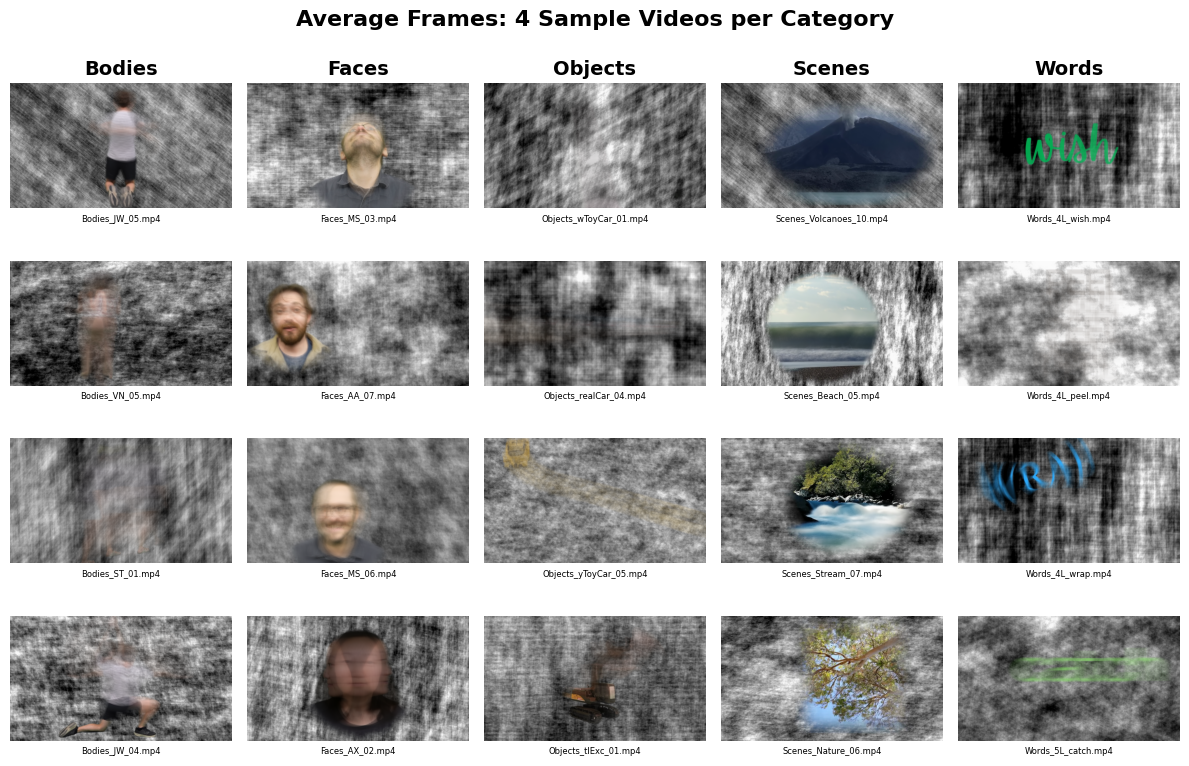

In [7]:
import random

random.seed(0)  # reproducible sample across reruns

fig, axes = plt.subplots(4, 5, figsize=(12, 8))

for col, (folder, category) in enumerate(target_folders.items()):
    folder_path = os.path.join(base_dir, folder)
    mov_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.mp4')])
    sampled = random.sample(mov_files, min(4, len(mov_files)))

    for row, fname in enumerate(sampled):
        video_path = os.path.join(folder_path, fname)
        cap = cv2.VideoCapture(video_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).astype(np.float32))
        cap.release()

        if not frames:
            continue

        mean_frame = np.mean(frames, axis=0).astype(np.uint8)

        ax = axes[row, col]
        ax.imshow(mean_frame)
        ax.axis('off')

        # Label top row with category name
        if row == 0:
            ax.set_title(category, fontsize=14, fontweight='bold')

        # ✅ Show full (or trimmed) filename below each image
        ax.text(
            0.5, -0.05,          # centered just below the image
            fname[:30],          # show up to 30 chars
            transform=ax.transAxes,
            fontsize=6,
            ha='center',
            va='top',
            color='black',
            wrap=True
        )

plt.suptitle("Average Frames: 4 Sample Videos per Category", fontsize=16, fontweight='bold')
plt.tight_layout(h_pad = 0.5)
today = date.today().isoformat()
plt.savefig(f"SKAdynaloc_sample_avg_frames_forpixelwiserdm_{today}.png", dpi=200, bbox_inches="tight")
plt.show()

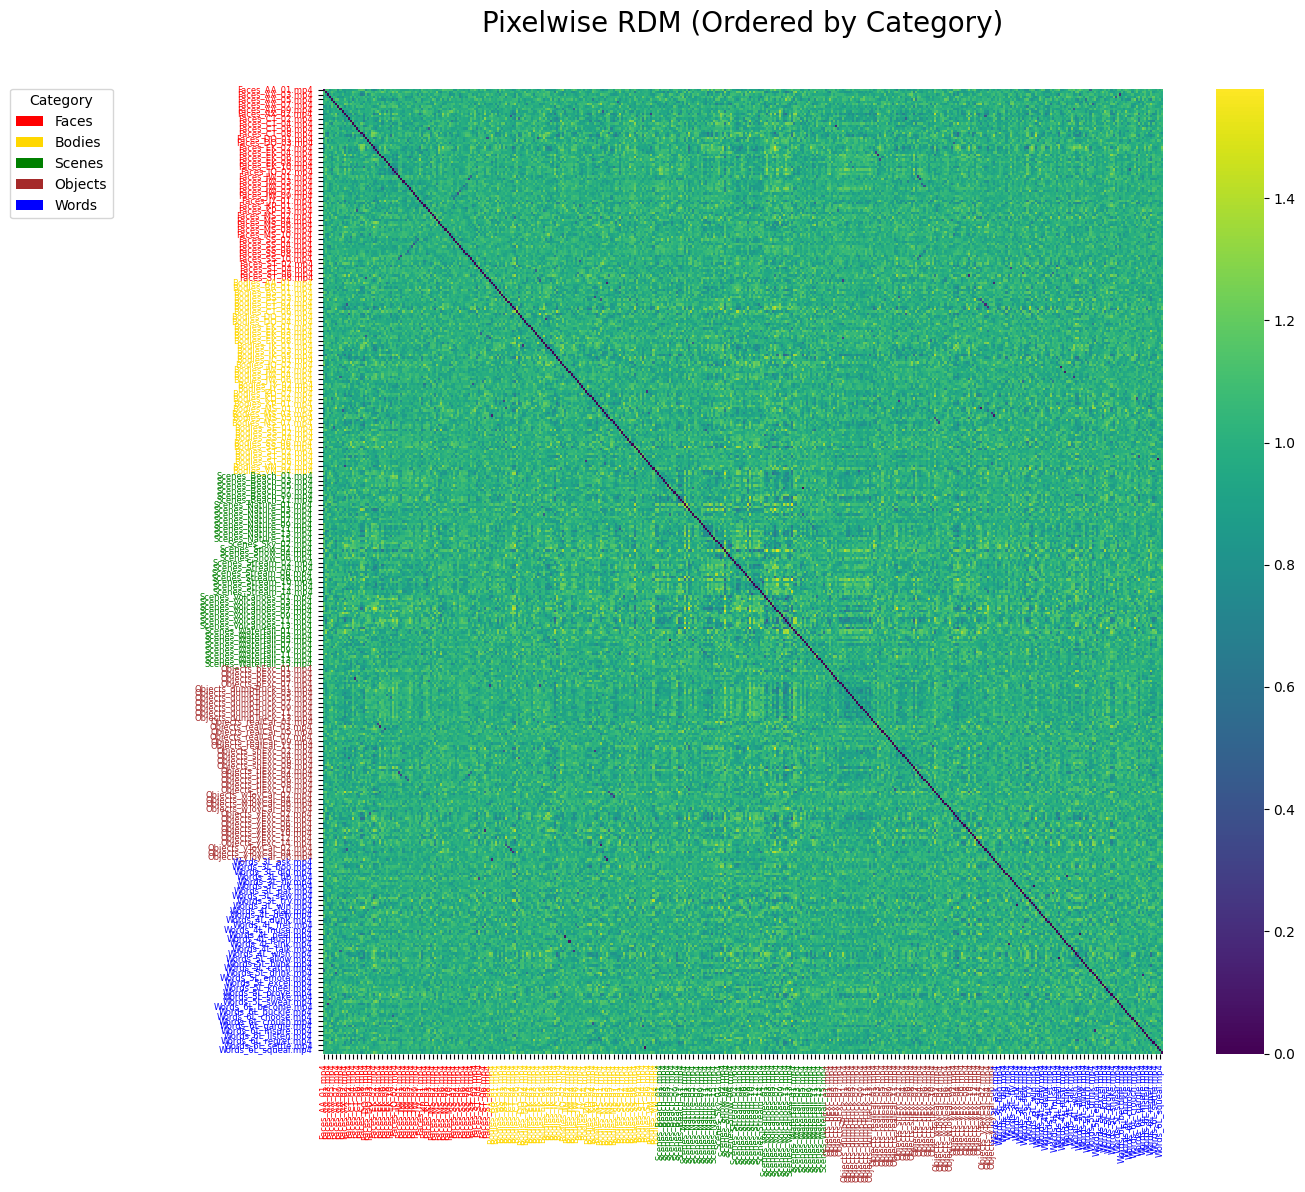

In [4]:

# Computing the RDM and plotting the heatmap

# Category order and colors for visualization
cat_order = ["Faces", "Bodies", "Scenes", "Objects", "Words"]
cat2color = {
    "Faces": "red",
    "Bodies": "gold",
    "Scenes": "green",
    "Objects": "brown",
    "Words": "blue"
}

# Sort by category and video name
sorted_indices = sorted(
    range(len(video_labels)),
    key=lambda i: (cat_order.index(video_categories[i]), video_labels[i])
)
pixelwise_features_sorted = pixelwise_features[sorted_indices]
labels_sorted = [video_labels[i] for i in sorted_indices]
cats_sorted = [video_categories[i] for i in sorted_indices]

# Compute dissimilarity using correlation distance
pixelwise_rdm = squareform(pdist(pixelwise_features_sorted, metric='correlation'))

# ----------------------
# COLOR ASSIGNMENT
# ----------------------
label_colors = [cat2color[cat] for cat in cats_sorted]

# ----------------------
# PLOT
# ----------------------
plt.figure(figsize=(14, 12))
ax = sns.heatmap(pixelwise_rdm, xticklabels=False, yticklabels=False, cmap='viridis')

# Show every nth tick
label_freq = 2
tick_indices = np.arange(len(labels_sorted))[::label_freq]

# X tick labels
ax.set_xticks(tick_indices + 0.5)
ax.set_xticklabels([labels_sorted[i] for i in tick_indices], rotation=90, fontsize=6)
for xtick, color in zip(ax.get_xticklabels(), [label_colors[i] for i in tick_indices]):
    xtick.set_color(color)

# Y tick labels
ax.set_yticks(tick_indices + 0.5)
ax.set_yticklabels([labels_sorted[i] for i in tick_indices], rotation=0, fontsize=6)
for ytick, color in zip(ax.get_yticklabels(), [label_colors[i] for i in tick_indices]):
    ytick.set_color(color)

# Legend for categories
legend_elements = [Patch(facecolor=cat2color[cat], label=cat) for cat in cat_order]
ax.legend(
    handles=legend_elements,
    title="Category",
    bbox_to_anchor=(-0.25, 1),
    loc="upper right",
    borderaxespad=0
)

today = date.today().isoformat()  # YYYY-MM-DD

plt.title("Pixelwise RDM (Ordered by Category)", y=1.05, fontsize=20)
plt.tight_layout()

plt.savefig(f"pixelwise_rdm_all_categories_{today}.png",
            dpi=300, bbox_inches="tight")
plt.show()


#### Section 4: Pixelwise Grayscale RDM (Low-level Visual Similarity, incorporates frames)

This analysis computes a representational dissimilarity matrix (RDM) based on smoothed grayscale pixel values across all video frames. Following Kriegeskorte et al. (2008), videos are converted to the perceptually uniform LAB color space, extracting only the L (luminance) channel to create grayscale representations. Each frame is smoothed with a Gaussian kernel (σ=5, approximating FWHM=11.75 pixels) to reduce high-frequency noise and model early visual processing. All frames from each video are concatenated into a single high-dimensional vector, preserving both spatial patterns (which pixels are bright/dark) and temporal dynamics (how brightness changes across frames). Videos are then compared using correlation distance, revealing which videos share similar low-level visual structure independent of semantic content. This approach captures static appearance patterns and temporal evolution of luminance, complementing higher-level or motion-based representations.

I borrowed this from a published paper that used these while building RDMs for an RSA, but it's super memory intensive, and the motion energy model in the other notebook would be better for motion features. 
Due to high dimensionality (~30M features × 400 videos ≈ 47GB), this implementation
includes several memory management strategies, and takes ages to run.

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from skimage import color
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch
import warnings

# ----------------------
# SETTINGS
# ----------------------
base_dir = os.environ.get("DYLOC_STIMULI_DIR", "./stimuli")  # folder with dyloc_bodies/dyloc_faces/dyloc_objects/dyloc_scenes/dyloc_words subfolders
target_folders = {
    'dyloc_bodies': 'Bodies',
    'dyloc_faces': 'Faces',
    'dyloc_objects': 'Objects',
    'dyloc_scenes': 'Scenes',
    'dyloc_words': 'Words'
}

cat_order = ["Faces", "Bodies", "Scenes", "Objects", "Words"]
cat2color = {
    "Faces": "red",
    "Bodies": "gold",
    "Scenes": "green",
    "Objects": "brown",
    "Words": "blue"
}

# ----------------------
# FEATURE EXTRACTION
# ----------------------
def load_grayscale_smooth_frames(video_path, sigma=5):
    """Load a video and return its smoothed grayscale (LAB L-channel) frames, flattened."""
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        rgb_normalized = np.clip(rgb.astype(np.float32) / 255.0, 0, 1)

        # Convert to LAB and keep the L (luminance) channel
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            lab = color.rgb2lab(rgb_normalized)
        gray = lab[:, :, 0].astype(np.float32)

        gray_smooth = gaussian_filter(gray, sigma=sigma)
        frames.append(gray_smooth.flatten())

    cap.release()

    if not frames:
        raise ValueError(f"No frames found in {video_path}")

    return np.array(frames, dtype=np.float32).flatten()

# ----------------------
# LOAD VIDEOS
# ----------------------
# NOTE: this holds one flattened, smoothed feature vector per video in memory
# at once. At the full ~30M-features x 400-videos scale mentioned above, that
# does not comfortably fit in RAM -- if you hit that scale, extract features
# in batches and accumulate the RDM incrementally instead of all at once.
print("Loading and processing videos...")
video_vectors = []
video_labels = []
video_categories = []

for folder, category in target_folders.items():
    folder_path = os.path.join(base_dir, folder)
    if not os.path.isdir(folder_path):
        print(f"Skipping {folder_path} (not found)")
        continue

    print(f"Processing category: {category}")
    video_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.mp4')])

    for idx, fname in enumerate(video_files, 1):
        video_path = os.path.join(folder_path, fname)
        try:
            vec = load_grayscale_smooth_frames(video_path)
            video_vectors.append(vec)
            video_labels.append(fname)
            video_categories.append(category)
        except Exception as e:
            print(f"Failed to process {fname}: {e}")

        if idx % 10 == 0:
            print(f"  ...{idx}/{len(video_files)} done")

print(f"\nLoaded {len(video_vectors)} videos")

# Frame counts can differ slightly between videos; truncate to the shortest
# so all feature vectors are the same length before stacking.
min_length = min(len(v) for v in video_vectors)
X = np.stack([v[:min_length] for v in video_vectors])
del video_vectors

# ----------------------
# SORT BY CATEGORY
# ----------------------
sorted_indices = np.argsort([cat_order.index(cat) for cat in video_categories])
X_sorted = X[sorted_indices]
labels_sorted = [video_labels[i] for i in sorted_indices]
cats_sorted = [video_categories[i] for i in sorted_indices]

print(f"Feature matrix shape: {X_sorted.shape}")


In [ ]:
import os

# ----------------------
# CACHE FEATURES TO DISK (so you don't have to recompute if you restart)
# ----------------------
save_dir = os.path.join(base_dir, "motion_rdm_cache")
os.makedirs(save_dir, exist_ok=True)

cache_path = os.path.join(save_dir, "grayscale_smooth_features.npz")
np.savez_compressed(
    cache_path,
    X_sorted=X_sorted.astype(np.float32),
    labels_sorted=np.array(labels_sorted),
    cats_sorted=np.array(cats_sorted),
    cat_order=np.array(cat_order),
)

print(f"Saved features cache: {cache_path}")


In [ ]:
# ----------------------
# COMPUTE RDM (correlation distance)
# ----------------------
rdm = squareform(pdist(X_sorted, metric='correlation'))

print(f"RDM shape: {rdm.shape}")
print(f"Memory: {rdm.nbytes / (1024**2):.1f} MB")


In [ ]:
# Save the RDM so that you don't have to compute it all over again
out_path = "rdm_pixelwise_grayscale_corrdist.npy"
np.save(out_path, rdm.astype(np.float32))

In [ ]:
# Reordering so that the video names are ordered alphabetically 
import numpy as np

# Ensure these exist:
# cat_order = ["Faces", "Bodies", "Scenes", "Objects", "Words"]
# cat2color = {...}

# Convert to arrays for safe indexing
labels = np.array(labels_sorted)
cats   = np.array(cats_sorted)

# Map categories to ranks according to your desired order
cat_rank = {cat: i for i, cat in enumerate(cat_order)}

cat_ranks = np.array([cat_rank[c] for c in cats])

# New permutation: primary = category rank, secondary = filename
# lexsort sorts by last key first, so (labels, cat_ranks) => cat_ranks primary, labels tie-break
new_order = np.lexsort((labels, cat_ranks))

# Reindex everything consistently
rdm = rdm[np.ix_(new_order, new_order)]
labels_sorted = labels[new_order].tolist()
cats_sorted = cats[new_order].tolist()
label_colors = [cat2color[c] for c in cats_sorted]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

# ----------------------
# Category → color map
# ----------------------
cat2color = {
    'Faces': 'red',
    'Bodies': 'gold',
    'Scenes': 'green',
    'Objects': 'brown',
    'Words': 'blue'
}

# Colors aligned with sorted labels
label_colors = [cat2color[c] for c in cats_sorted]

# ----------------------
# Plot heatmap (RDM already sorted)
# ----------------------
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    rdm,
    cmap="viridis",
    square=True,
    xticklabels=False,
    yticklabels=False
)

# ----------------------
# Tick configuration
# ----------------------
label_freq = 2   # show every Nth label
tick_indices = np.arange(0, len(labels_sorted), label_freq)

# X ticks
ax.set_xticks(tick_indices + 0.5)
ax.set_xticklabels(
    [labels_sorted[i] for i in tick_indices],
    rotation=90,
    fontsize=6
)
for tick, i in zip(ax.get_xticklabels(), tick_indices):
    tick.set_color(label_colors[i])

# Y ticks
ax.set_yticks(tick_indices + 0.5)
ax.set_yticklabels(
    [labels_sorted[i] for i in tick_indices],
    rotation=0,
    fontsize=6
)
for tick, i in zip(ax.get_yticklabels(), tick_indices):
    tick.set_color(label_colors[i])

# ----------------------
# Legend
# ----------------------
legend_elements = [
    Patch(facecolor=color, label=cat)
    for cat, color in cat2color.items()
]

ax.legend(
    handles=legend_elements,
    title="Category",
    bbox_to_anchor=(-0.28, 1),
    loc="upper left",
    borderaxespad=0
)

# ----------------------
# Final touches
# ----------------------
plt.title("Pixelwise Grayscale RDM (Across Frames, Sorted by Category)", fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig(
    "pixelwise_grayscale_rdm_acrossframes_kriegeskortestyle_fewerlabels.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
# ----------------------
# SUMMARY STATISTICS
# ----------------------
print("\n Summary Statistics:")
print(f"Mean correlation distance: {np.mean(rdm[np.triu_indices_from(rdm, k=1)]):.3f}")
print(f"Std correlation distance: {np.std(rdm[np.triu_indices_from(rdm, k=1)]):.3f}")

# Within-category vs between-category distances
within_cat_dists = []
between_cat_dists = []

for i in range(len(cats_sorted)):
    for j in range(i+1, len(cats_sorted)):
        if cats_sorted[i] == cats_sorted[j]:
            within_cat_dists.append(rdm[i, j])
        else:
            between_cat_dists.append(rdm[i, j])

if within_cat_dists and between_cat_dists:
    print(f"\nWithin-category distance: {np.mean(within_cat_dists):.3f} ± {np.std(within_cat_dists):.3f}")
    print(f"Between-category distance: {np.mean(between_cat_dists):.3f} ± {np.std(between_cat_dists):.3f}")

#### Section 6: Custom motion based RDM 

Just another way to assess Farneback optic flow across frames, focuses on magnitude not direction, you could incorporate that too. This is custom code, other methods here are probably better.

In [ ]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

base_dir = os.environ.get("DYLOC_STIMULI_DIR", "./stimuli")  # folder with dyloc_bodies/dyloc_faces/dyloc_objects/dyloc_scenes/dyloc_words subfolders
target_folders = {
    'dyloc_bodies': 'Bodies',
    'dyloc_faces': 'Faces',
    'dyloc_objects': 'Objects',
    'dyloc_scenes': 'Scenes',
    'dyloc_words': 'Words'
}


# ---- 1. Compute motion timecourses for all videos ----
motion_timecourses = {}
video_labels = []
category_labels = []

for folder, label in target_folders.items():
    folder_path = os.path.join(base_dir, folder)
    if not os.path.isdir(folder_path):
        print(f"Skipping {folder_path} (not found)")
        continue
    print(f"Processing category: {label}")
    for fname in os.listdir(folder_path):
        if not fname.endswith(".mp4"):
            continue
        path = os.path.join(folder_path, fname)
        cap = cv2.VideoCapture(path)
        ret, prev_frame = cap.read()
        if not ret:
            continue
        prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
        mags = []

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            flow = cv2.calcOpticalFlowFarneback(
                prev_gray, gray, None,
                pyr_scale=0.5, levels=3, winsize=15,
                iterations=3, poly_n=5, poly_sigma=1.2, flags=0
            )
            mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
            mags.append(np.mean(mag))
            prev_gray = gray
        cap.release()

        motion_timecourses[f"{label}_{fname}"] = np.array(mags)
        video_labels.append(f"{label}_{fname}")
        category_labels.append(label)

# ---- 2. Align by shortest video ----
min_len = min(len(v) for v in motion_timecourses.values())
motion_matrix = np.stack([v[:min_len] for v in motion_timecourses.values()])

# ---- 3. Compute RDM (1 - correlation) ----
rdm = 1 - np.corrcoef(motion_matrix)



In [ ]:
# ---- 4. Sort by category----
sorted_indices = []
for cat in np.unique(category_labels):
    cat_indices = np.where(np.array(category_labels) == cat)[0]
    sorted_indices.extend(cat_indices)

sorted_labels = np.array(category_labels)[sorted_indices]
rdm_sorted = rdm[np.ix_(sorted_indices, sorted_indices)]

# ---- 5. Define category colors ----
cat_colors = {
    'Faces': 'red',
    'Bodies': 'gold',
    'Scenes': 'green',
    'Objects': 'brown',
    'Words': 'blue'
}

# ---- 6. Plot the RDM ----
plt.figure(figsize=(9, 8))
sns.heatmap(
    rdm_sorted,
    cmap="viridis",
    square=True,
    cbar_kws={'label': '1 - r'},
    xticklabels=False,
    yticklabels=False
)
plt.title("Motion-based RDM (All Categories)", fontsize=16)

# Add category labels on the y-axis
unique_cats = list(dict.fromkeys(sorted_labels))  # preserve overall order
for cat in unique_cats:
    indices = np.where(sorted_labels == cat)[0]
    mid = np.mean(indices)
    plt.text(-3, mid, cat, va='center', ha='right',
             fontsize=12, color=cat_colors[cat], weight='bold')

plt.tight_layout()
plt.savefig("motion_rdm_all_categories_shuffled_truesize.png", dpi=300, bbox_inches='tight')
plt.show()